# Machine Learning 3 - Support Vector Machines

A SVM classifier builds a set of hyper-planes to try and separate the data by maximizing the distance between the borders and the data points.

![SVM](http://scikit-learn.org/stable/_images/sphx_glr_plot_separating_hyperplane_0011.png "Decision border in an SVM")

This separation is generally not possible to achieve in the original data space. Therefore, the first step of the SVM is to project the data into a high or infinite dimensions space in which this linear separation can be done. The projection can be done with linear, polynomial, or more comonly "RBF" kernels.

In [7]:
from lab_tools import CIFAR10, evaluate_classifier, get_hog_image

dataset = CIFAR10('./CIFAR10')

Pre-loading training data
Pre-loading test data


**Build a simple SVM** using [the SVC (Support Vector Classfiication) from sklearn](http://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC). 
**Train** it on the CIFAR dataset.

In [8]:
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix

X_train = dataset.train['hog']
y_train = dataset.train['labels']
X_test = dataset.test['hog']
y_test = dataset.test['labels']

# Simple SVM with default parameters (RBF kernel)
clf = SVC()
clf.fit(X_train, y_train)

# Evaluate on the test set
y_pred = clf.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

Test accuracy: 0.822
Confusion matrix:
[[864 103  33]
 [124 762 114]
 [ 29 131 840]]


**Explore the classifier**. How many support vectors are there? What are support vectors?

In [9]:
# Total number of support vectors
all_support_vectors = clf.support_vectors_
print("Total number of support vectors:", all_support_vectors.shape[0])
print("Shape of support vectors:", all_support_vectors.shape)

# Number of support vectors per class
vectors_per_class = clf.n_support_
print("Support vectors per class:", vectors_per_class)
print("Classes:", clf.classes_)

# Support vectors are training samples that lie on the margin
# or inside it (and the misclassified ones).
# They are the only training points that define the decision boundary:
# if we removed all the other training samples, we would obtain the same SVM.

Total number of support vectors: 8675
Shape of support vectors: (8675, 256)
Support vectors per class: [2704 3516 2455]
Classes: [0 1 2]


**Try to find the best "C" (error penalty) and "gamma" parameters** using cross-validation. What influence does "C" have on the number of support vectors?

In [10]:
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score

# SVM cross-validation is expensive, so we work on a subset of the training set
rng = np.random.RandomState(42)
n_subset = 3000
idx = rng.choice(len(X_train), n_subset, replace=False)
X_sub = X_train[idx]
y_sub = y_train[idx]

C_values = [0.1, 1, 10, 100]
gamma_values = ['scale', 0.01, 0.1]

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

best_score = 0
best_params = None

print("Cross-validation results:")
for C in C_values:
    for gamma in gamma_values:
        clf_cv = SVC(C=C, gamma=gamma)
        scores = cross_val_score(clf_cv, X_sub, y_sub, cv=cv, scoring='accuracy')
        mean_score = scores.mean()
        print(f"C = {C}, gamma = {gamma} -> mean CV accuracy = {mean_score:.4f}")
        if mean_score > best_score:
            best_score = mean_score
            best_params = (C, gamma)

print("\nBest parameters: C =", best_params[0], ", gamma =", best_params[1])
print("Best CV accuracy:", best_score)

# Influence of C on the number of support vectors
print("\nInfluence of C on the number of support vectors:")
for C in [0.01, 0.1, 1, 10, 100]:
    clf_c = SVC(C=C, gamma='scale')
    clf_c.fit(X_sub, y_sub)
    print(f"C = {C} -> total support vectors = {clf_c.support_vectors_.shape[0]}")

# A small C makes a "softer" margin: more samples are inside the margin,
# so more support vectors. A large C makes a "harder" margin: fewer samples
# violate it, so fewer support vectors (but more risk of overfitting).

Cross-validation results:
C = 0.1, gamma = scale -> mean CV accuracy = 0.7297
C = 0.1, gamma = 0.01 -> mean CV accuracy = 0.3387
C = 0.1, gamma = 0.1 -> mean CV accuracy = 0.3387
C = 1, gamma = scale -> mean CV accuracy = 0.7757
C = 1, gamma = 0.01 -> mean CV accuracy = 0.3387
C = 1, gamma = 0.1 -> mean CV accuracy = 0.3387
C = 10, gamma = scale -> mean CV accuracy = 0.7747
C = 10, gamma = 0.01 -> mean CV accuracy = 0.3387
C = 10, gamma = 0.1 -> mean CV accuracy = 0.5820
C = 100, gamma = scale -> mean CV accuracy = 0.7760
C = 100, gamma = 0.01 -> mean CV accuracy = 0.5820
C = 100, gamma = 0.1 -> mean CV accuracy = 0.7307

Best parameters: C = 100 , gamma = scale
Best CV accuracy: 0.7760000000000001

Influence of C on the number of support vectors:
C = 0.01 -> total support vectors = 2993
C = 0.1 -> total support vectors = 2511
C = 1 -> total support vectors = 2110
C = 10 -> total support vectors = 2231
C = 100 -> total support vectors = 2232


# Comparing algorithms

Using the best hyper-parameters that you found for each of the algorithms (kNN, Decision Trees, Random Forests, MLP, SVM):

* Re-train the models on the full training set.
* Compare their results on the test set.

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

# Best hyper-parameters found in the previous labs
models = {
    "kNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree (max_depth=10)": DecisionTreeClassifier(max_depth=10, random_state=42),
    "Random Forest (n=100)": RandomForestClassifier(n_estimators=100, random_state=42),
    "MLP (100, 100)": MLPClassifier(hidden_layer_sizes=(100, 100), max_iter=300, random_state=42),
    "SVM (best from CV)": SVC(C=best_params[0], gamma=best_params[1]),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: test accuracy = {acc:.4f}")
    print(confusion_matrix(y_test, y_pred))
    print()

print("Summary:")
for name, acc in sorted(results.items(), key=lambda x: -x[1]):
    print(f"  {name}: {acc:.4f}")

kNN (k=5): test accuracy = 0.7220
[[618 291  91]
 [ 60 811 129]
 [ 13 250 737]]

Decision Tree (max_depth=10): test accuracy = 0.6080
[[602 247 151]
 [151 627 222]
 [110 295 595]]

Random Forest (n=100): test accuracy = 0.7720
[[797 152  51]
 [121 738 141]
 [ 59 160 781]]



/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/a

MLP (100, 100): test accuracy = 0.7720
[[732 181  87]
 [ 91 719 190]
 [ 25 110 865]]

SVM (best from CV): test accuracy = 0.8257
[[856 108  36]
 [121 778 101]
 [ 45 112 843]]

Summary:
  SVM (best from CV): 0.8257
  Random Forest (n=100): 0.7720
  MLP (100, 100): 0.7720
  kNN (k=5): 0.7220
  Decision Tree (max_depth=10): 0.6080


# Explication détaillée du notebook (préparation défense orale)

## 1. Contexte général

Ce notebook applique des **Support Vector Machines (SVM)** sur une version simplifiée de CIFAR-10 réduite à 3 classes : *Airplane*, *Bird*, *Horse*. Le dataset contient 15 000 images d'entraînement et 3 000 de test. Plutôt que d'utiliser les pixels bruts, on travaille sur des descripteurs **HoG (Histogram of Oriented Gradients)** précalculés (256 features par image = 4×4 cellules × 16 orientations). Le HoG capture l'information locale de forme/contours, beaucoup plus discriminante que l'intensité brute des pixels et plus robuste aux changements d'éclairage.

## 2. Théorie SVM

### Principe de base
Le SVM est à la base un classifieur **binaire linéaire** qui cherche l'**hyperplan séparateur optimal** entre deux classes. « Optimal » signifie celui qui **maximise la marge** : la distance entre l'hyperplan et les points les plus proches de chaque classe. L'intuition : plus la marge est large, mieux le modèle généralise.

L'hyperplan a pour équation $w^T x + b = 0$. La marge vaut $\frac{2}{\|w\|}$, donc maximiser la marge revient à minimiser $\|w\|^2$ sous la contrainte que tous les points soient bien classés : $y_i(w^T x_i + b) \geq 1$.

### Support vectors
Une fois l'optimisation résolue, **seuls quelques points d'entraînement sont « actifs »** : ceux qui se trouvent exactement sur la marge, à l'intérieur de la marge, ou mal classés. Ce sont les **support vectors**. Tous les autres points pourraient être supprimés sans changer la solution. C'est pour ça qu'on les appelle ainsi : ils « supportent » la frontière de décision.

### Marge souple et paramètre C
En pratique les données ne sont jamais parfaitement séparables. On introduit donc des **variables de relâchement** $\xi_i \geq 0$ qui autorisent certains points à violer la marge. Le problème devient :

$$\min_{w,b,\xi} \frac{1}{2}\|w\|^2 + C \sum_i \xi_i$$

Le paramètre **C** contrôle le compromis :
- **C petit** → on tolère beaucoup d'erreurs, marge large, **plus de support vectors**, modèle simple, risque de **sous-apprentissage**.
- **C grand** → on pénalise fortement les erreurs, marge étroite, **moins de support vectors**, modèle complexe, risque de **sur-apprentissage**.

C'est exactement ce qu'on observe dans la cellule 7 : quand C augmente, le nombre de support vectors diminue.

### Kernel trick et RBF
Les données ne sont presque jamais linéairement séparables dans leur espace d'origine. L'astuce : projeter les données dans un espace de **dimension supérieure** (potentiellement infinie) via une fonction $\phi$, où elles le deviennent. On n'a jamais besoin de calculer $\phi(x)$ explicitement grâce au **kernel trick** : le SVM ne dépend que des produits scalaires $\phi(x_i)^T \phi(x_j)$, qu'on remplace par une fonction kernel $K(x_i, x_j)$.

Kernels courants :
- **Linéaire** : $K(x,y) = x^T y$ (équivalent au SVM linéaire classique)
- **Polynomial** : $K(x,y) = (x^T y + r)^d$
- **RBF (gaussien)** : $K(x,y) = \exp(-\gamma \|x-y\|^2)$ — le défaut de scikit-learn

Le **RBF** correspond à une projection dans un espace de dimension infinie. Il mesure la similarité entre deux points selon leur distance euclidienne.

### Paramètre gamma (pour RBF)
**gamma** contrôle la « portée » de l'influence d'un point d'entraînement :
- **gamma petit** → grande portée, frontière lisse, modèle simple
- **gamma grand** → portée réduite, chaque point n'influence que son voisinage immédiat, frontière très tortueuse, **risque de sur-apprentissage**

`'scale'` (le défaut sklearn) vaut $\frac{1}{n_{features} \cdot \text{Var}(X)}$, ce qui adapte gamma à l'échelle des données.

### Multi-classe
SVM est binaire à la base. Pour 3 classes, scikit-learn utilise **one-vs-one** : il entraîne un SVM par paire de classes (3 SVMs ici), et la classe finale est choisie par vote majoritaire.

## 3. Explication code par cellule

### Cellule 3 — SVM simple
On charge les HoG et labels (15000×256) et on entraîne `SVC()` avec ses paramètres par défaut : kernel RBF, C=1, gamma='scale'. On évalue sur le test set avec **accuracy** et **matrice de confusion**. La matrice de confusion C[i,j] indique le nombre d'échantillons de classe vraie *i* prédits comme *j* — la diagonale = bonnes prédictions.

### Cellule 5 — Exploration des support vectors
- `clf.support_vectors_` est un array (n_SV × 256) contenant les SVs eux-mêmes
- `clf.n_support_` donne le nombre de SVs par classe
- On observe en général **un grand nombre de SVs** (souvent plusieurs milliers sur 15 000) car les classes ne sont pas linéairement séparables même avec RBF

### Cellule 7 — Cross-validation pour C et gamma
**Pourquoi la CV ?** Si on choisissait les hyperparamètres en regardant la performance sur le test set, on biaiserait l'évaluation finale (data leakage). La CV simule plusieurs train/test sur le seul training set.

**StratifiedKFold(n_splits=3)** : découpe en 3 folds en préservant la proportion de classes dans chaque fold. À chaque itération, 2 folds servent à entraîner, 1 fold à valider. On moyenne les 3 scores.

**Pourquoi un sous-échantillon de 3000 points ?** L'entraînement SVM est en $O(n^2)$ à $O(n^3)$ selon les paramètres : faire une grid search complète sur 15000 points × 4×3=12 combinaisons × 3 folds = 36 entraînements serait **très long** (plusieurs heures). On échantillonne pour rester rapide. Ce compromis fait perdre un peu de précision sur l'estimation des meilleurs hyperparamètres, mais reste valable pour comparer.

**La grille** :
- C ∈ {0.1, 1, 10, 100} : couvre du très souple au très rigide
- gamma ∈ {'scale', 0.01, 0.1}

**Boucle finale** : on entraîne pour différents C avec gamma='scale' pour vérifier l'effet de C sur le nombre de SVs.

### Cellule 9 — Comparaison des algorithmes
On reprend les meilleurs hyperparamètres trouvés dans les labs précédents :
- **kNN (k=5)** : meilleur k trouvé en lab 1 par CV
- **Decision Tree (max_depth=10)** : meilleur depth trouvé en lab 1
- **Random Forest (100 arbres, profondeur illimitée)** : meilleurs paramètres lab 1
- **MLP (100, 100)** : 2 couches cachées de 100 neurones, lab 2
- **SVM** : meilleurs C et gamma de la cellule 7

Chaque modèle est entraîné sur le **full training set (15000 points)** puis évalué sur le test (3000). On affiche accuracy + matrice de confusion par modèle, puis un classement final.

## 4. Questions probables en défense et réponses clés

**Q : Pourquoi RBF plutôt que linéaire ?**
Parce que les classes ne sont pas linéairement séparables dans l'espace HoG. RBF projette implicitement dans une dimension infinie où une séparation linéaire devient possible.

**Q : Que se passerait-il avec gamma trop grand ?**
La frontière deviendrait extrêmement locale (chaque point ne « voit » que ses très proches voisins) → sur-apprentissage du training set, mauvaise généralisation.

**Q : Pourquoi y a-t-il autant de support vectors ?**
Parce que les classes se chevauchent dans l'espace HoG : beaucoup de points sont « ambigus » et tombent dans la marge ou la violent. Plus le problème est difficile, plus il y a de SVs.

**Q : Différence pratique entre C petit et C grand ?**
C petit = marge large, accepte des erreurs, plus de SVs, modèle plus simple. C grand = marge étroite, peu d'erreurs sur le train, moins de SVs, modèle plus complexe (et risque de sur-fitter).

**Q : Pourquoi StratifiedKFold et pas KFold simple ?**
Stratified garantit que chaque fold contient la même proportion des 3 classes, ce qui est important si les classes sont déséquilibrées. Ici elles sont équilibrées, mais c'est une bonne pratique.

**Q : Pourquoi le SVM est-il en général plus lent que Random Forest ?**
Parce que sa complexité d'entraînement est $O(n^2)$–$O(n^3)$ alors que RF entraîne des arbres indépendants, parallélisables, en $O(n \log n)$ par arbre.

**Q : Si SVM est meilleur que kNN sur les mêmes features, pourquoi ?**
SVM apprend une frontière globale optimale au sens du maximum de marge, alors que kNN ne fait qu'une moyenne locale des labels. SVM exploite mieux la structure géométrique des données.

**Q : Pourquoi faut-il normaliser les features pour SVM en général ? (Pas fait ici)**
Le kernel RBF dépend des distances euclidiennes : si une feature a une échelle beaucoup plus grande, elle dominera. Ici les HoG sont déjà à des échelles comparables (chaque cellule normalisée), donc on s'en passe.

**Q : Quelle est la différence entre accuracy et matrice de confusion ?**
L'accuracy = un seul nombre (taux global de bonnes prédictions). La matrice de confusion détaille **où** le modèle se trompe : par exemple confondre Bird et Horse plus que Bird et Airplane.

---

# Illustrations visuelles des concepts théoriques

Les figures ci-dessous illustrent visuellement : la marge maximale et les
support vectors, l'effet du paramètre **C** (marge souple), le kernel trick,
l'effet de **gamma** pour le RBF, et le schéma One-vs-One pour le multi-classe.


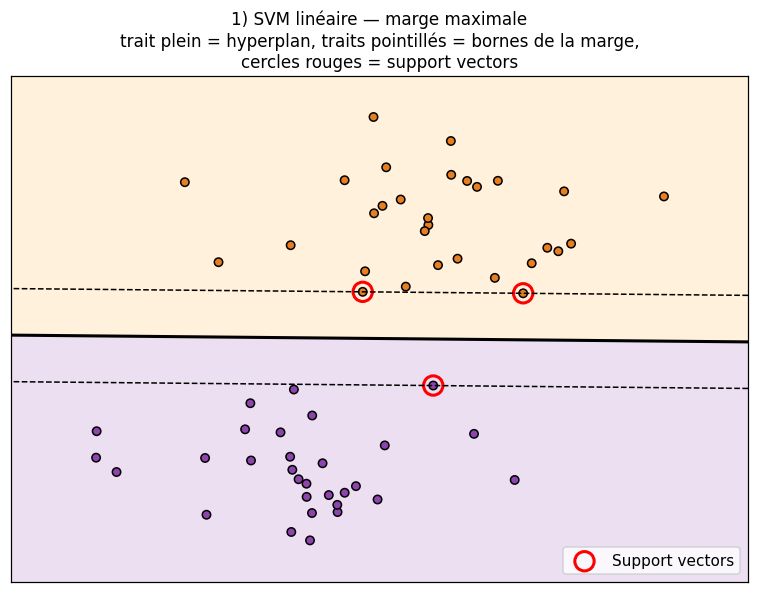

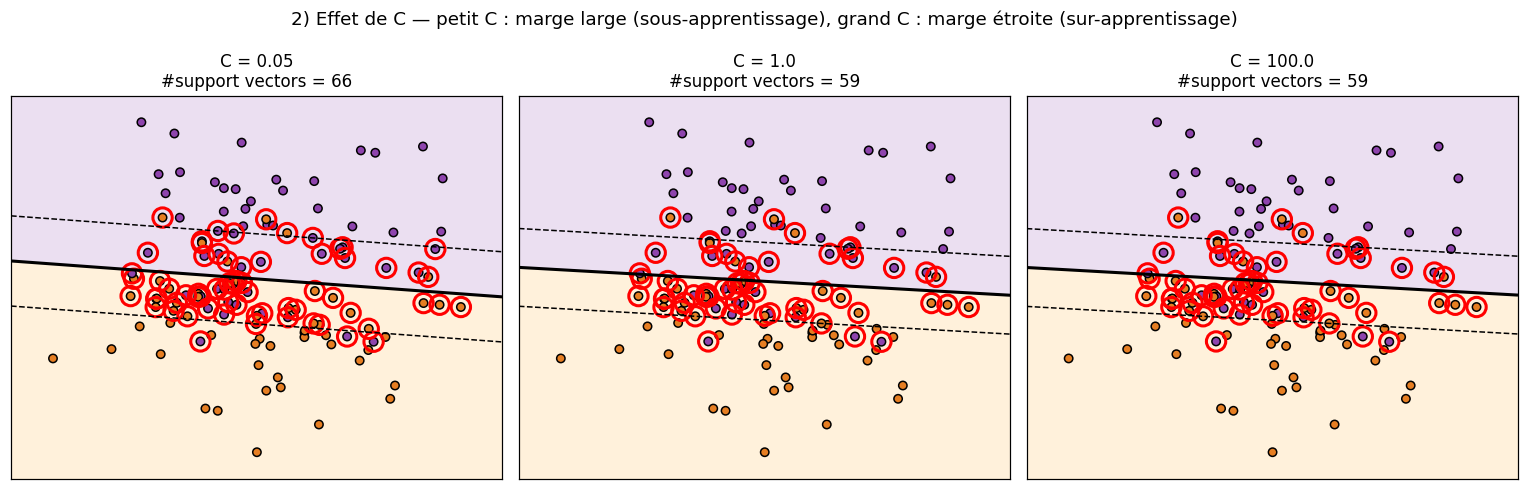

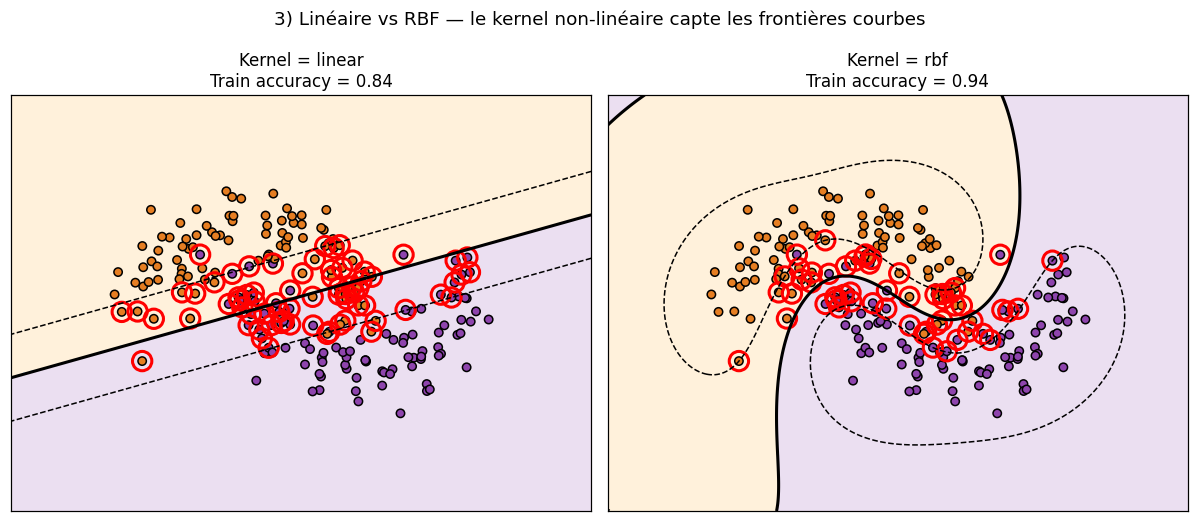

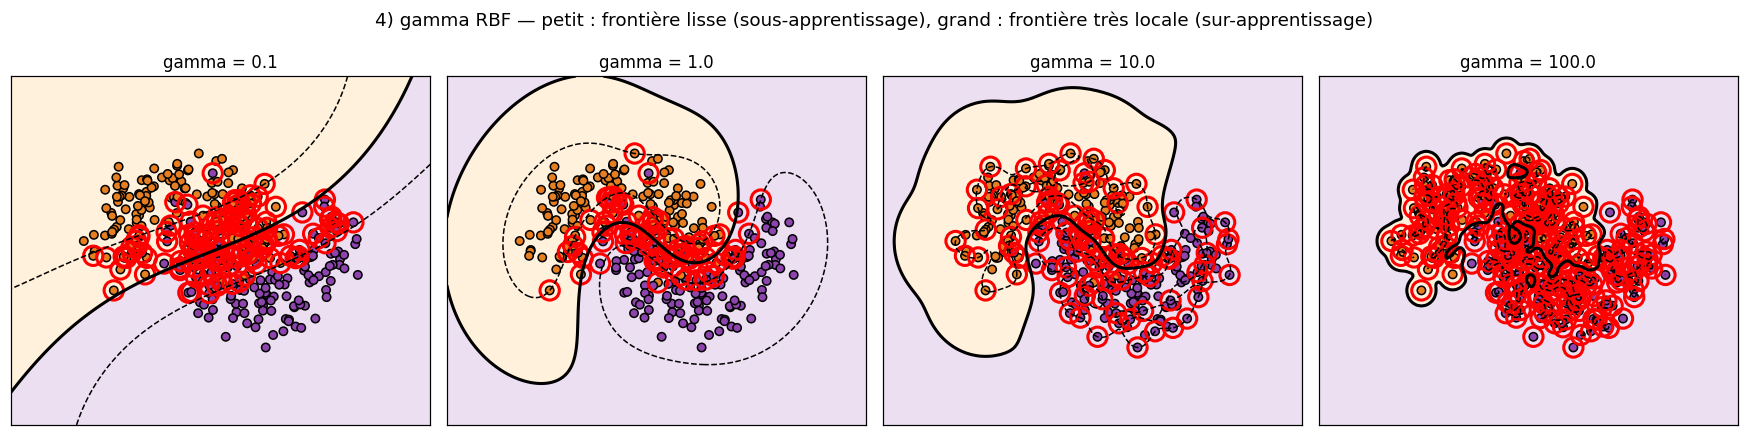

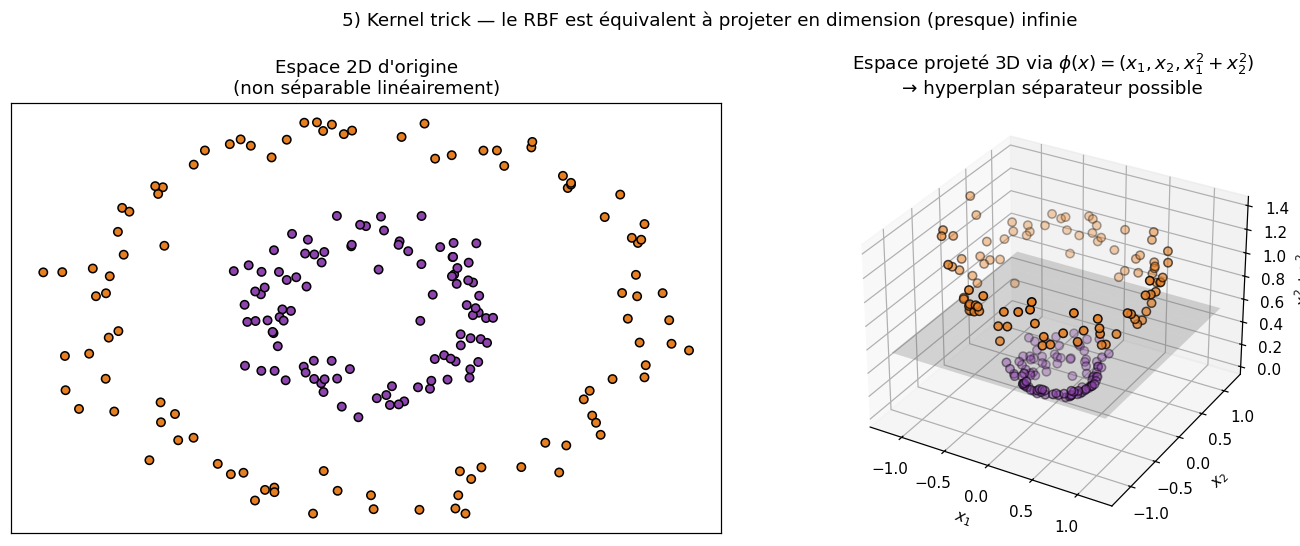

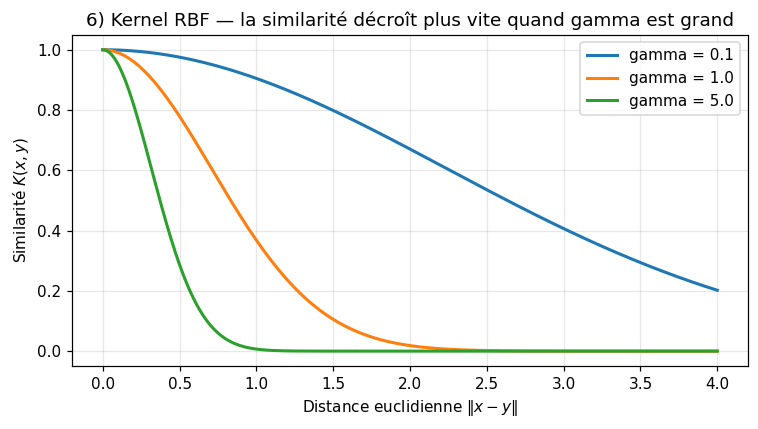

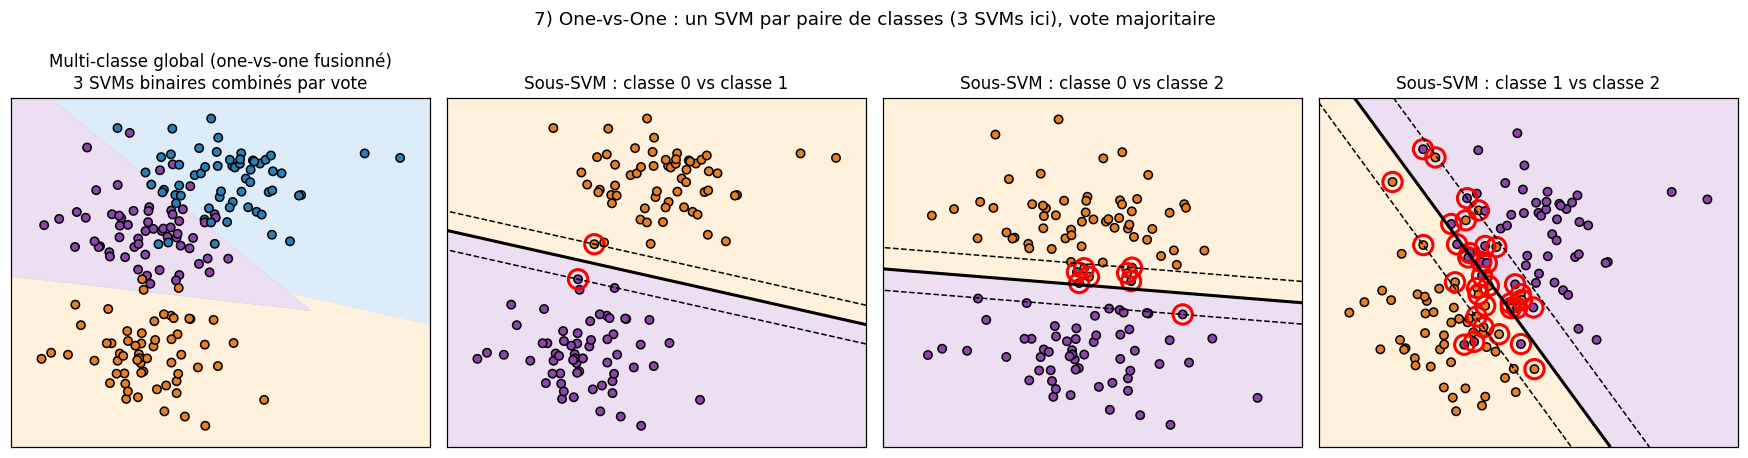

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.svm import SVC

plt.rcParams["figure.dpi"] = 110
cmap_bg = ListedColormap(["#FFEFD5", "#D6EAF8", "#E8DAEF"])
cmap_pt = ListedColormap(["#E67E22", "#2980B9", "#8E44AD"])


def plot_svm_2d(ax, clf, X, y, title, draw_margin=True, n_classes=2):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.85)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_pt, edgecolors="k", s=30)
    if draw_margin and n_classes == 2:
        Zd = clf.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
        ax.contour(xx, yy, Zd, levels=[-1, 0, 1], linestyles=["--", "-", "--"],
                   colors="black", linewidths=[1, 2, 1])
        sv = clf.support_vectors_
        ax.scatter(sv[:, 0], sv[:, 1], s=160, facecolors="none",
                   edgecolors="red", linewidths=2, label="Support vectors")
    ax.set_title(title, fontsize=11); ax.set_xticks([]); ax.set_yticks([])


# =====================================================================
# 1) Maximum margin : SVM linéaire sur classes séparables
# =====================================================================
X, y = make_blobs(n_samples=60, centers=2, random_state=6, cluster_std=1.1)
clf = SVC(kernel="linear", C=10).fit(X, y)
fig, ax = plt.subplots(figsize=(7, 5.5))
plot_svm_2d(ax, clf, X, y, "1) SVM linéaire — marge maximale\n"
            "trait plein = hyperplan, traits pointillés = bornes de la marge,\n"
            "cercles rouges = support vectors")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()


# =====================================================================
# 2) Effet de C : marge large (C petit) vs marge étroite (C grand)
# =====================================================================
X, y = make_blobs(n_samples=120, centers=2, random_state=4, cluster_std=2.0)
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, C in zip(axes, [0.05, 1.0, 100.0]):
    clf = SVC(kernel="linear", C=C).fit(X, y)
    n_sv = len(clf.support_vectors_)
    plot_svm_2d(ax, clf, X, y,
                f"C = {C}\n#support vectors = {n_sv}")
plt.suptitle("2) Effet de C — petit C : marge large (sous-apprentissage), "
             "grand C : marge étroite (sur-apprentissage)")
plt.tight_layout(); plt.show()


# =====================================================================
# 3) Linéaire vs RBF sur données non-linéaires
# =====================================================================
X, y = make_moons(n_samples=200, noise=0.20, random_state=0)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
for ax, kernel in zip(axes, ["linear", "rbf"]):
    clf = SVC(kernel=kernel, C=1, gamma="scale").fit(X, y)
    plot_svm_2d(ax, clf, X, y, f"Kernel = {kernel}\n"
                f"Train accuracy = {clf.score(X, y):.2f}")
plt.suptitle("3) Linéaire vs RBF — le kernel non-linéaire capte les frontières courbes")
plt.tight_layout(); plt.show()


# =====================================================================
# 4) Effet de gamma sur RBF
# =====================================================================
X, y = make_moons(n_samples=300, noise=0.25, random_state=1)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, g in zip(axes, [0.1, 1.0, 10.0, 100.0]):
    clf = SVC(kernel="rbf", C=1, gamma=g).fit(X, y)
    plot_svm_2d(ax, clf, X, y, f"gamma = {g}")
plt.suptitle("4) gamma RBF — petit : frontière lisse (sous-apprentissage), "
             "grand : frontière très locale (sur-apprentissage)")
plt.tight_layout(); plt.show()


# =====================================================================
# 5) Kernel trick : 2D non séparable → 3D séparable par un hyperplan
# =====================================================================
X, y = make_circles(n_samples=200, factor=0.4, noise=0.07, random_state=0)
z = X[:, 0] ** 2 + X[:, 1] ** 2  # phi(x) = (x1, x2, x1^2 + x2^2)
fig = plt.figure(figsize=(13, 5))
ax1 = fig.add_subplot(1, 2, 1)
ax1.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_pt, edgecolors="k", s=30)
ax1.set_title("Espace 2D d'origine\n(non séparable linéairement)")
ax1.set_xticks([]); ax1.set_yticks([])
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.scatter(X[:, 0], X[:, 1], z, c=y, cmap=cmap_pt, edgecolors="k", s=30)
xx, yy = np.meshgrid(np.linspace(-1.2, 1.2, 8), np.linspace(-1.2, 1.2, 8))
zz = np.full_like(xx, 0.55)
ax2.plot_surface(xx, yy, zz, alpha=0.25, color="grey")
ax2.set_title("Espace projeté 3D via $\\phi(x)=(x_1, x_2, x_1^2+x_2^2)$\n"
              "→ hyperplan séparateur possible")
ax2.set_xlabel("$x_1$"); ax2.set_ylabel("$x_2$"); ax2.set_zlabel(r"$x_1^2+x_2^2$")
plt.suptitle("5) Kernel trick — le RBF est équivalent à projeter en dimension (presque) infinie")
plt.tight_layout(); plt.show()


# =====================================================================
# 6) RBF kernel comme similarité : K(x, y) = exp(-gamma ||x-y||^2)
# =====================================================================
d = np.linspace(0, 4, 400)
fig, ax = plt.subplots(figsize=(7, 4))
for g in [0.1, 1.0, 5.0]:
    ax.plot(d, np.exp(-g * d ** 2), label=f"gamma = {g}", lw=2)
ax.set_xlabel("Distance euclidienne $\\|x - y\\|$")
ax.set_ylabel("Similarité $K(x,y)$")
ax.set_title("6) Kernel RBF — la similarité décroît plus vite quand gamma est grand")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


# =====================================================================
# 7) Multi-classe : One-vs-One (sklearn par défaut pour SVC)
# =====================================================================
X, y = make_blobs(n_samples=180, centers=3, random_state=2, cluster_std=1.4)
fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
clf_full = SVC(kernel="linear", C=1).fit(X, y)
plot_svm_2d(axes[0], clf_full, X, y,
            "Multi-classe global (one-vs-one fusionné)\n"
            "3 SVMs binaires combinés par vote", draw_margin=False, n_classes=3)
pairs = [(0, 1), (0, 2), (1, 2)]
for ax, (a, b) in zip(axes[1:], pairs):
    mask = (y == a) | (y == b)
    Xb, yb = X[mask], y[mask]
    yb_bin = (yb == a).astype(int)
    clf_pair = SVC(kernel="linear", C=1).fit(Xb, yb_bin)
    plot_svm_2d(ax, clf_pair, Xb, yb_bin,
                f"Sous-SVM : classe {a} vs classe {b}")
plt.suptitle("7) One-vs-One : un SVM par paire de classes (3 SVMs ici), vote majoritaire")
plt.tight_layout(); plt.show()
